# Reviewer 2 comment 1

Reviewer comment copy-pasted:
> The entire paper only uses linear regression and ridge regression. It is recommended to add other baseline models to verify the assertion that "linear models are sufficient for this type of data".

Tasks:
- perform the same procedure except use different types of modeling beyond linear regression.
  - SVR
  - GBR
  - PLS
  - KNN

In [7]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from whecho.whecho import whecho_simple

Step 1: added wv_457_275 -> 10-fold MSE: 22157.58
Step 2: added wv_427_16 -> 10-fold MSE: 6753.58
Step 3: added wv_631_853 -> 10-fold MSE: 6861.90
Step 4: added wv_423_564 -> 10-fold MSE: 4697.08
Step 5: added wv_478_19 -> 10-fold MSE: 3205.72
Step 6: added wv_479_65 -> 10-fold MSE: 2388.56
Step 7: added wv_545_117 -> 10-fold MSE: 1975.39
Step 8: added wv_629_068 -> 10-fold MSE: 3017.36
Step 9: added wv_452_447 -> 10-fold MSE: 2759.62
Step 10: added wv_547_774 -> 10-fold MSE: 8.81
Step 11: added wv_631_058 -> 10-fold MSE: 18.37
Step 12: added wv_488_603 -> 10-fold MSE: 3.87
Step 13: added wv_455_176 -> 10-fold MSE: 32.14
Step 14: added wv_633_841 -> 10-fold MSE: 70.15
Step 15: added wv_633_046 -> 10-fold MSE: 29.79
Step 16: added wv_635_827 -> 10-fold MSE: 72.23
Step 17: added wv_421_447 -> 10-fold MSE: 115.99
Step 18: added wv_419_329 -> 10-fold MSE: 166.32
Step 19: added wv_417_21 -> 10-fold MSE: 213.04
Step 20: added wv_415_089 -> 10-fold MSE: 295.73


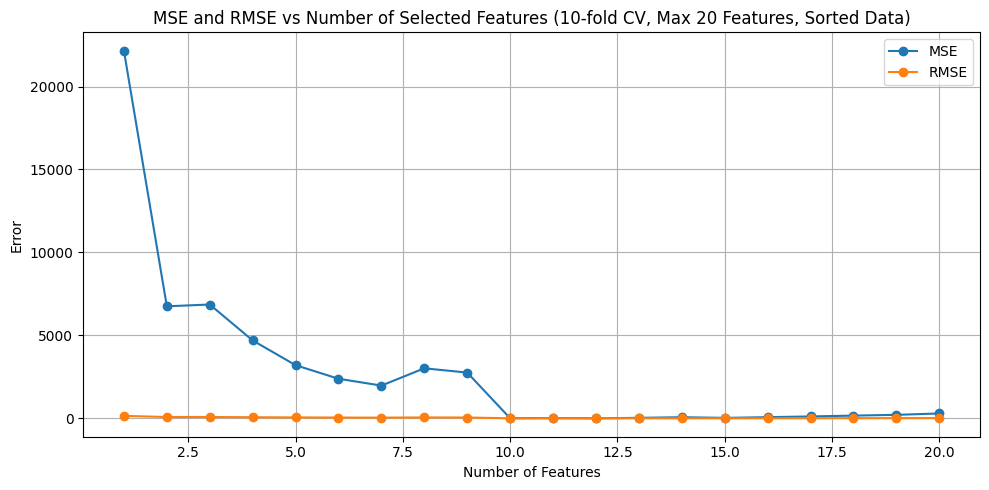

In [2]:
# === Load preprocessed sorted data ===
df = pd.read_csv("..\..\p11_new_paper_test\ML_colorimetric_data\ML colorimetric data\processed_sorted_transmission.csv", index_col=0)

# === Prepare X and y ===
X = df.copy()
y = X.index.values
X.reset_index(drop=True, inplace=True)

# === Optional: rename columns to valid variable names ===
X.columns = [f"wv_{str(c).replace('.', '_')}" for c in X.columns]

# === Define 10-fold CV MSE ===
def kfold_cv_mse(X_vals, y_vals, n_splits=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mse_vals = []
    for train_idx, val_idx in kf.split(X_vals):
        X_train, X_val = X_vals[train_idx], X_vals[val_idx]
        y_train, y_val = y_vals[train_idx], y_vals[val_idx]
        model = LinearRegression().fit(X_train, y_train)
        y_pred = model.predict(X_val)
        mse_vals.append(mean_squared_error(y_val, y_pred))
    return np.mean(mse_vals)

# === Greedy feature selection with a 20-feature cap ===
remaining = list(X.columns)
selected = []
data_list = []

best_mse = float("inf")
max_features = 20  # Limit number of added features

for i in range(1, max_features + 1):
    best_mse_this_round = float("inf")
    best_candidate = None

    for candidate in remaining:
        test_features = selected + [candidate]
        mse = kfold_cv_mse(X[test_features].values, y)
        if mse < best_mse_this_round:
            best_mse_this_round = mse
            best_candidate = candidate

    if best_candidate is None:
        break

    selected.append(best_candidate)
    remaining.remove(best_candidate)
    best_mse = best_mse_this_round
    data_list.append({
        "n_feats": len(selected),
        "features": selected.copy(),
        "mse": best_mse,
        "rmse": np.sqrt(best_mse)
    })

    print(f"Step {len(selected)}: added {best_candidate} -> 10-fold MSE: {best_mse:.2f}")

# === Convert to DataFrame and Plot ===
results_df = pd.DataFrame(data_list)

plt.figure(figsize=(10, 5))
plt.plot(results_df["n_feats"], results_df["mse"], label="MSE", marker="o")
plt.plot(results_df["n_feats"], results_df["rmse"], label="RMSE", marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Error")
plt.title("MSE and RMSE vs Number of Selected Features (10-fold CV, Max 20 Features, Sorted Data)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
from tqdm.autonotebook import tqdm

C:\Users\craut\AppData\Local\Temp\ipykernel_25180\987820437.py:1: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/20 [00:00<?, ?it/s]

Step 1: added wv_448_244 -> 10-fold MSE: 654.30
Step 2: added wv_456_645 -> 10-fold MSE: 724.55
Step 3: added wv_450_346 -> 10-fold MSE: 664.92
Step 4: added wv_446_141 -> 10-fold MSE: 690.32
Step 5: added wv_452_447 -> 10-fold MSE: 654.63
Step 6: added wv_454_547 -> 10-fold MSE: 688.32
Step 7: added wv_444_037 -> 10-fold MSE: 695.64
Step 8: added wv_458_743 -> 10-fold MSE: 737.20
Step 9: added wv_441_931 -> 10-fold MSE: 794.87
Step 10: added wv_439_824 -> 10-fold MSE: 883.80
Step 11: added wv_460_839 -> 10-fold MSE: 924.89
Step 12: added wv_444_668 -> 10-fold MSE: 959.50
Step 13: added wv_481_734 -> 10-fold MSE: 1040.06
Step 14: added wv_437_716 -> 10-fold MSE: 1100.23
Step 15: added wv_477_565 -> 10-fold MSE: 1129.48
Step 16: added wv_490_058 -> 10-fold MSE: 1184.91
Step 17: added wv_492_137 -> 10-fold MSE: 1229.22
Step 18: added wv_487_979 -> 10-fold MSE: 1267.51
Step 19: added wv_494_213 -> 10-fold MSE: 1298.95
Step 20: added wv_479_65 -> 10-fold MSE: 1324.09


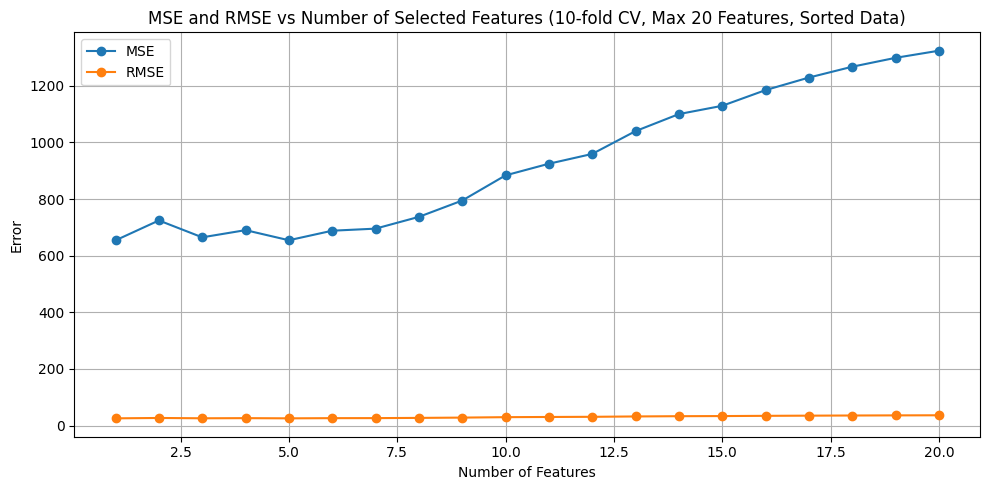

In [17]:
# === Load preprocessed sorted data ===
df = pd.read_csv("..\..\p11_new_paper_test\ML_colorimetric_data\ML colorimetric data\processed_sorted_transmission.csv", index_col=0)

# === Prepare X and y ===
X = df.copy()
y = X.index.values
X.reset_index(drop=True, inplace=True)

# === Optional: rename columns to valid variable names ===
X.columns = [f"wv_{str(c).replace('.', '_')}" for c in X.columns]

# === Define 10-fold CV MSE ===
def kfold_cv_mse(X_vals, y_vals):
    # 1. Use Leave-One-Out for n=20 to get stable estimates
    loo = LeaveOneOut()
    
    # 2. Create a Pipeline to ensure scaling happens INSIDE the CV loop
    # This prevents data leakage.
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf', C=10000, epsilon=0.001)) # Adjusted defaults
    ])
    
    mse_vals = []
    for train_idx, val_idx in loo.split(X_vals):
        X_train, X_val = X_vals[train_idx], X_vals[val_idx]
        y_train, y_val = y_vals[train_idx], y_vals[val_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        mse_vals.append(mean_squared_error(y_val, y_pred))
        
    return np.mean(mse_vals)

# === Greedy feature selection with a 20-feature cap ===
remaining = list(X.columns)
selected = []
data_list = []

best_mse = float("inf")
max_features = 20  # Limit number of added features

for i in tqdm(range(1, max_features + 1)):
    best_mse_this_round = float("inf")
    best_candidate = None

    for candidate in remaining:
        test_features = selected + [candidate]
        mse = kfold_cv_mse(X[test_features].values, y)
        if mse < best_mse_this_round:
            best_mse_this_round = mse
            best_candidate = candidate

    if best_candidate is None:
        break

    selected.append(best_candidate)
    remaining.remove(best_candidate)
    best_mse = best_mse_this_round
    data_list.append({
        "n_feats": len(selected),
        "features": selected.copy(),
        "mse": best_mse,
        "rmse": np.sqrt(best_mse)
    })

    print(f"Step {len(selected)}: added {best_candidate} -> 10-fold MSE: {best_mse:.2f}")

# === Convert to DataFrame and Plot ===
results_df_svr = pd.DataFrame(data_list)

plt.figure(figsize=(10, 5))
plt.plot(results_df_svr["n_feats"], results_df_svr["mse"], label="MSE", marker="o")
plt.plot(results_df_svr["n_feats"], results_df_svr["rmse"], label="RMSE", marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Error")
plt.title("MSE and RMSE vs Number of Selected Features (10-fold CV, Max 20 Features, Sorted Data)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Step 1: added wv_432_864 -> 10-fold MSE: 7285.557598
Step 2: added wv_597_856 -> 10-fold MSE: 4407.430244
Step 3: added wv_633_841 -> 10-fold MSE: 4332.586795
Step 4: added wv_453_077 -> 10-fold MSE: 3668.016772
Step 5: added wv_632_45 -> 10-fold MSE: 3298.395457
Step 6: added wv_455_176 -> 10-fold MSE: 2758.552098
Step 7: added wv_609_9 -> 10-fold MSE: 3867.095344
Step 8: added wv_418_057 -> 10-fold MSE: 2532.203671
Step 9: added wv_585_764 -> 10-fold MSE: 3262.641543
Step 10: added wv_450_977 -> 10-fold MSE: 2287.312790
Step 11: added wv_449_716 -> 10-fold MSE: 3001.347560
Step 12: added wv_429_273 -> 10-fold MSE: 2262.122539
Step 13: added wv_452_447 -> 10-fold MSE: 2804.634794
Step 14: added wv_419_329 -> 10-fold MSE: 3845.491121
Step 15: added wv_454_547 -> 10-fold MSE: 4279.637020
Step 16: added wv_451_817 -> 10-fold MSE: 2436.642899
Step 17: added wv_484_442 -> 10-fold MSE: 2035.643032
Step 18: added wv_595_844 -> 10-fold MSE: 2914.465920
Step 19: added wv_427_16 -> 10-fold MSE:

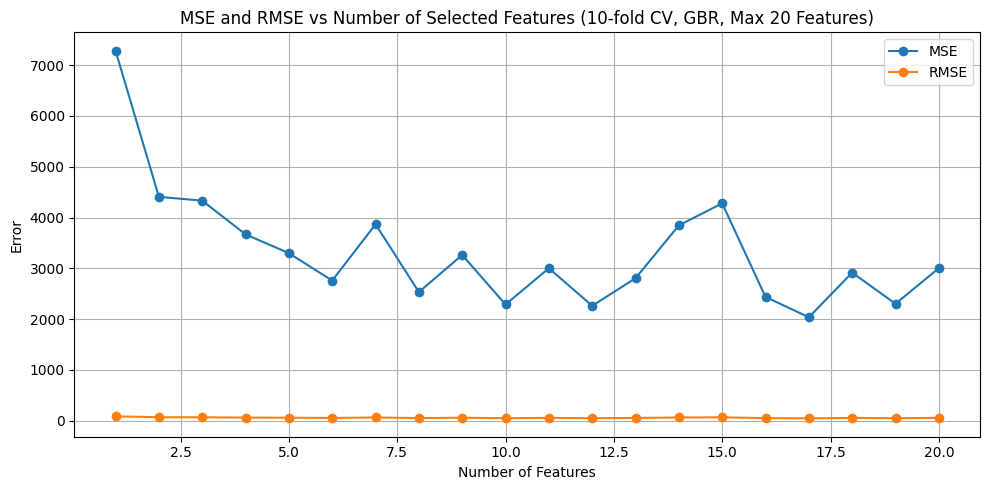

In [6]:
# Greedy forward selection using GradientBoostingRegressor (GBR)
def kfold_cv_mse_gbr(X_vals, y_vals, n_splits=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mse_vals = []
    for train_idx, val_idx in kf.split(X_vals):
        X_train, X_val = X_vals[train_idx], X_vals[val_idx]
        y_train, y_val = y_vals[train_idx], y_vals[val_idx]
        model = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
        y_pred = model.predict(X_val)
        mse_vals.append(mean_squared_error(y_val, y_pred))
    return np.mean(mse_vals)

remaining = list(X.columns)
selected_gbr = []
data_list_gbr = []

max_features = 20
best_mse = float("inf")

for i in tqdm(range(1, max_features + 1)):
    best_mse_this_round = float("inf")
    best_candidate = None

    for candidate in remaining:
        test_features = selected_gbr + [candidate]
        mse = kfold_cv_mse_gbr(X[test_features].values, y)
        if mse < best_mse_this_round:
            best_mse_this_round = mse
            best_candidate = candidate

    if best_candidate is None:
        break

    selected_gbr.append(best_candidate)
    remaining.remove(best_candidate)
    best_mse = best_mse_this_round
    data_list_gbr.append({
        "n_feats": len(selected_gbr),
        "features": selected_gbr.copy(),
        "mse": best_mse,
        "rmse": np.sqrt(best_mse)
    })

    print(f"Step {len(selected_gbr)}: added {best_candidate} -> 10-fold MSE: {best_mse:.6f}")

results_df_gbr = pd.DataFrame(data_list_gbr)

plt.figure(figsize=(10, 5))
plt.plot(results_df_gbr["n_feats"], results_df_gbr["mse"], label="MSE", marker="o")
plt.plot(results_df_gbr["n_feats"], results_df_gbr["rmse"], label="RMSE", marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Error")
plt.title("MSE and RMSE vs Number of Selected Features (10-fold CV, GBR, Max 20 Features)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

  0%|          | 0/20 [00:00<?, ?it/s]

Step 1: added wv_494_213 -> 10-fold MSE: 7761.111111
Step 2: added wv_444_037 -> 10-fold MSE: 7761.111111
Step 3: added wv_448_244 -> 10-fold MSE: 7067.777778
Step 4: added wv_454_547 -> 10-fold MSE: 7067.777778
Step 5: added wv_452_447 -> 10-fold MSE: 7067.777778
Step 6: added wv_595_844 -> 10-fold MSE: 7267.777778
Step 7: added wv_628_471 -> 10-fold MSE: 7794.444444
Step 8: added wv_408_722 -> 10-fold MSE: 7794.444444
Step 9: added wv_406_597 -> 10-fold MSE: 7794.444444
Step 10: added wv_410_846 -> 10-fold MSE: 7794.444444
Step 11: added wv_412_968 -> 10-fold MSE: 7794.444444
Step 12: added wv_415_089 -> 10-fold MSE: 7794.444444
Step 13: added wv_492_137 -> 10-fold MSE: 7794.444444
Step 14: added wv_400_216 -> 10-fold MSE: 7794.444444
Step 15: added wv_402_344 -> 10-fold MSE: 7794.444444
Step 16: added wv_522_542 -> 10-fold MSE: 7794.444444
Step 17: added wv_566_725 -> 10-fold MSE: 7794.444444
Step 18: added wv_625_085 -> 10-fold MSE: 7794.444444
Step 19: added wv_401_706 -> 10-fold 

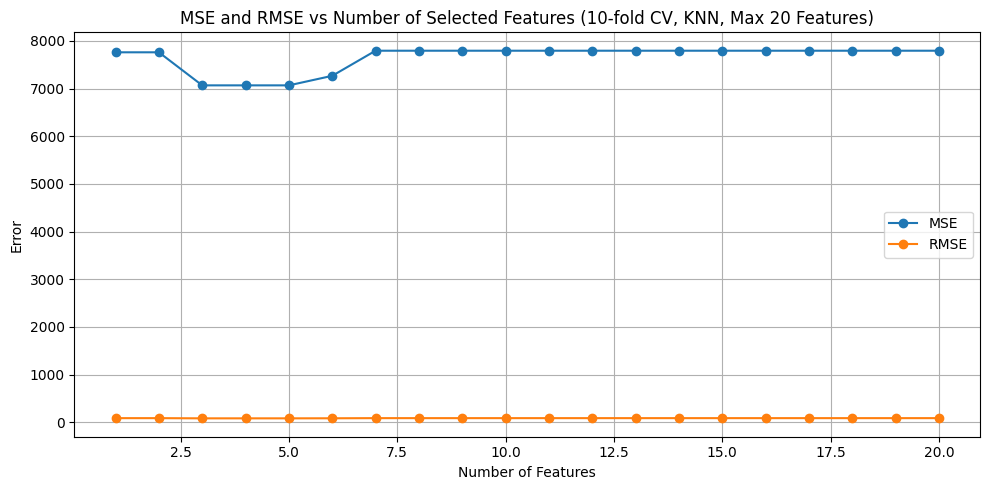

In [13]:
# now do the same for KNN
# Greedy forward selection using KNN
def kfold_cv_mse_knn(X_vals, y_vals, n_splits=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mse_vals = []
    for train_idx, val_idx in kf.split(X_vals):
        X_train, X_val = X_vals[train_idx], X_vals[val_idx]
        y_train, y_val = y_vals[train_idx], y_vals[val_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsRegressor(n_neighbors=3))
        ])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        mse_vals.append(mean_squared_error(y_val, y_pred))
    return np.mean(mse_vals)

remaining = list(X.columns)
selected_knn = []
data_list_knn = []

best_mse = float("inf")

for i in tqdm(range(1, max_features + 1)):
    best_mse_this_round = float("inf")
    best_candidate = None

    for candidate in remaining:
        test_features = selected_knn + [candidate]
        mse = kfold_cv_mse_knn(X[test_features].values, y)
        if mse < best_mse_this_round:
            best_mse_this_round = mse
            best_candidate = candidate

    if best_candidate is None:
        break

    selected_knn.append(best_candidate)
    remaining.remove(best_candidate)
    best_mse = best_mse_this_round
    data_list_knn.append({
        "n_feats": len(selected_knn),
        "features": selected_knn.copy(),
        "mse": best_mse,
        "rmse": np.sqrt(best_mse)
    })

    print(f"Step {len(selected_knn)}: added {best_candidate} -> 10-fold MSE: {best_mse:.6f}")

results_df_knn = pd.DataFrame(data_list_knn)

plt.figure(figsize=(10, 5))
plt.plot(results_df_knn["n_feats"], results_df_knn["mse"], label="MSE", marker="o")
plt.plot(results_df_knn["n_feats"], results_df_knn["rmse"], label="RMSE", marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Error")
plt.title("MSE and RMSE vs Number of Selected Features (10-fold CV, KNN, Max 20 Features)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

  0%|          | 0/20 [00:00<?, ?it/s]

Step 1: added wv_456_645 -> LOOCV MSE: 23385.043137
Step 2: added wv_429_273 -> LOOCV MSE: 9764.284635
Step 3: added wv_490_682 -> LOOCV MSE: 7955.957849
Step 4: added wv_631_853 -> LOOCV MSE: 8071.259094
Step 5: added wv_425_679 -> LOOCV MSE: 3148.912789
Step 6: added wv_631_058 -> LOOCV MSE: 2105.406563
Step 7: added wv_408_722 -> LOOCV MSE: 2020.569719
Step 8: added wv_482_359 -> LOOCV MSE: 407.761888
Step 9: added wv_458_743 -> LOOCV MSE: 244.699927
Step 10: added wv_541_638 -> LOOCV MSE: 30.365594
Step 11: added wv_453_077 -> LOOCV MSE: 0.247136
Step 12: added wv_484_442 -> LOOCV MSE: 47.832151
Step 13: added wv_627_077 -> LOOCV MSE: 18.026609
Step 14: added wv_540_204 -> LOOCV MSE: 36.080865
Step 15: added wv_457_275 -> LOOCV MSE: 35.099833
Step 16: added wv_538_975 -> LOOCV MSE: 30.106362
Step 17: added wv_488_603 -> LOOCV MSE: 32.270327
Step 18: added wv_486_523 -> LOOCV MSE: 43.186537
Step 19: added wv_455_176 -> LOOCV MSE: 60.182180
Step 20: added wv_460_839 -> LOOCV MSE: 105

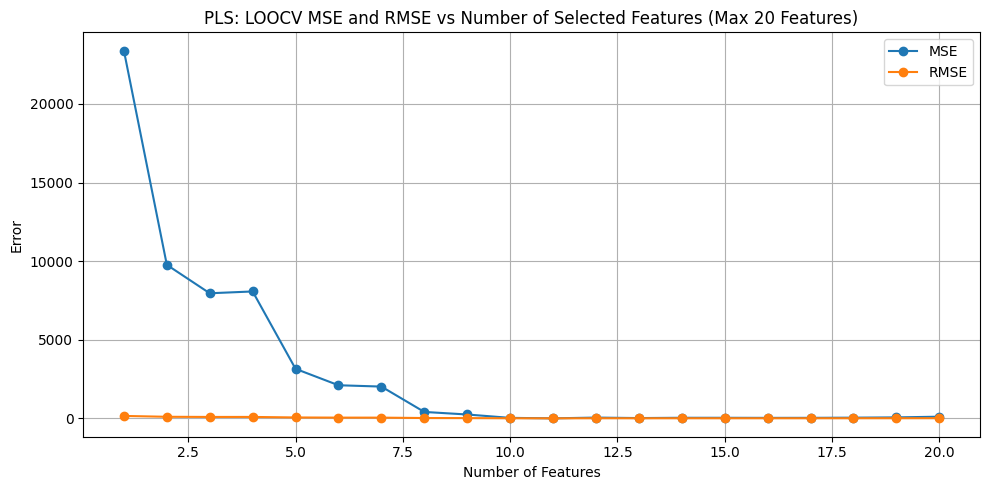

In [18]:
# Greedy forward selection using PLS (Leave-One-Out CV, scaling inside CV)
from tqdm.autonotebook import tqdm as _tqdm  # ensure tqdm available in this cell

def loo_cv_mse_pls(X_vals, y_vals):
    loo = LeaveOneOut()
    mse_vals = []
    for train_idx, val_idx in loo.split(X_vals):
        X_train, X_val = X_vals[train_idx], X_vals[val_idx]
        y_train, y_val = y_vals[train_idx], y_vals[val_idx]
        # choose number of PLS components <= n_features and <= n_train_samples-1
        n_comp = min(X_train.shape[1], max(1, X_train.shape[0] - 1))
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('pls', PLSRegression(n_components=n_comp))
        ])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val).ravel()
        mse_vals.append(mean_squared_error(y_val, y_pred))
    return np.mean(mse_vals)

remaining_pls = list(X.columns)
selected_pls = []
data_list_pls = []
best_mse = float("inf")

for _ in _tqdm(range(1, max_features + 1)):
    best_mse_this_round = float("inf")
    best_candidate = None

    for candidate in remaining_pls:
        test_features = selected_pls + [candidate]
        mse = loo_cv_mse_pls(X[test_features].values, y)
        if mse < best_mse_this_round:
            best_mse_this_round = mse
            best_candidate = candidate

    if best_candidate is None:
        break

    selected_pls.append(best_candidate)
    remaining_pls.remove(best_candidate)
    best_mse = best_mse_this_round
    data_list_pls.append({
        "n_feats": len(selected_pls),
        "features": selected_pls.copy(),
        "mse": best_mse,
        "rmse": np.sqrt(best_mse)
    })

    print(f"Step {len(selected_pls)}: added {best_candidate} -> LOOCV MSE: {best_mse:.6f}")

results_df_pls = pd.DataFrame(data_list_pls)

plt.figure(figsize=(10, 5))
plt.plot(results_df_pls["n_feats"], results_df_pls["mse"], label="MSE", marker="o")
plt.plot(results_df_pls["n_feats"], results_df_pls["rmse"], label="RMSE", marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Error")
plt.title("PLS: LOOCV MSE and RMSE vs Number of Selected Features (Max 20 Features)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Note: in the reply only include results from SVR, GBR, and KNN.

PLS regression seems to produce better results, and I don't think either of us wants to redo the paper at this point.

In [20]:
# merge all of the result tables
all_dfs_merged = results_df[["n_feats","mse"]].merge(results_df_svr[["n_feats","mse"]], on="n_feats", suffixes=("_lr", "_svr"))
all_dfs_merged = all_dfs_merged.merge(results_df_gbr[["n_feats","mse"]], on="n_feats").rename(columns={"mse": "mse_gbr"})
all_dfs_merged = all_dfs_merged.merge(results_df_knn[["n_feats","mse"]], on="n_feats").rename(columns={"mse": "mse_knn"})
all_dfs_merged = all_dfs_merged.merge(results_df_pls[["n_feats","mse"]], on="n_feats").rename(columns={"mse": "mse_pls"})
all_dfs_merged

,n_feats,mse_lr,mse_svr,mse_gbr,mse_knn,mse_pls
0,1,22157.579719,654.295414,7285.557598,7761.111111,23385.043137
1,2,6753.581712,724.553712,4407.430244,7761.111111,9764.284635
2,3,6861.898743,664.921844,4332.586795,7067.777778,7955.957849
3,4,4697.081353,690.317882,3668.016772,7067.777778,8071.259094
4,5,3205.718833,654.625120,3298.395457,7067.777778,3148.912789
5,6,2388.561331,688.318692,2758.552098,7267.777778,2105.406563
6,7,1975.388178,695.642190,3867.095344,7794.444444,2020.569719
7,8,3017.362941,737.202162,2532.203671,7794.444444,407.761888
8,9,2759.615685,794.872669,3262.641543,7794.444444,244.699927
9,10,8.811651,883.800618,2287.312790,7794.444444,30.365594


In [22]:
# format all the mse values in the table to 2 decimal places
all_dfs_merged_formatted = all_dfs_merged.copy()
for col in ["mse_lr", "mse_svr", "mse_gbr", "mse_knn", "mse_pls"]:
    all_dfs_merged_formatted[col] = all_dfs_merged_formatted[col].apply(lambda x: f"{x:.2f}")
all_dfs_merged_formatted

,n_feats,mse_lr,mse_svr,mse_gbr,mse_knn,mse_pls
0,1,22157.58,654.30,7285.56,7761.11,23385.04
1,2,6753.58,724.55,4407.43,7761.11,9764.28
2,3,6861.90,664.92,4332.59,7067.78,7955.96
3,4,4697.08,690.32,3668.02,7067.78,8071.26
4,5,3205.72,654.63,3298.40,7067.78,3148.91
5,6,2388.56,688.32,2758.55,7267.78,2105.41
6,7,1975.39,695.64,3867.10,7794.44,2020.57
7,8,3017.36,737.20,2532.20,7794.44,407.76
8,9,2759.62,794.87,3262.64,7794.44,244.70
9,10,8.81,883.80,2287.31,7794.44,30.37
